In [ ]:
!pip install -q torch torchvision transformers pillow matplotlib tqdm

In [ ]:
import os
import json
import math
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPProcessor, CLIPModel
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
DATASET_DIR   = "/content/drive/MyDrive/eng521/Grasp Point Prediction/data/pixmo_subset_v3"
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.json")
SPLITS_DIR    = os.path.join(DATASET_DIR, "splits")
TRAIN_PATH    = os.path.join(SPLITS_DIR, "train.json")
VAL_PATH      = os.path.join(SPLITS_DIR, "val.json")
TEST_PATH     = os.path.join(SPLITS_DIR, "test.json")
IMAGES_DIR    = os.path.join(DATASET_DIR, "images")

OUTPUT_DIR    = "/content/drive/MyDrive/eng521/Grasp Point Prediction/evaluation/Clip_v1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

MODEL_NAME = "openai/clip-vit-base-patch32"

BATCH_SIZE = 16
EPOCHS     = 20
LR         = 5e-5

DEVICE: cuda


In [ ]:
with open(TRAIN_PATH, "r") as f:
    train_data = json.load(f)
with open(VAL_PATH, "r") as f:
    val_data = json.load(f)
with open(TEST_PATH, "r") as f:
    test_data = json.load(f)

print("Train samples:", len(train_data))
print("Val samples:  ", len(val_data))
print("Test samples: ", len(test_data))
print("Example keys:", train_data[0].keys())

Train samples: 548
Val samples:   183
Test samples:  183
Example keys: dict_keys(['id', 'label', 'collection_method', 'count', 'points', 'image_path', 'image_url'])


In [ ]:
def normalized_to_unit(pt):
    return float(pt["x"]) / 100.0, float(pt["y"]) / 100.0

def normalized_to_pixel(pt, width, height):
    x = float(pt["x"]) / 100.0 * width
    y = float(pt["y"]) / 100.0 * height
    return (x, y)

def unit_to_pixel(pred_xy, width, height):
    x = float(pred_xy[0]) * width
    y = float(pred_xy[1]) * height
    return (x, y)

def average_point(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return (sum(xs) / len(xs), sum(ys) / len(ys))

def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

SUCCESS_THRESHOLD = 50

def normalized_pixel_error(err, w, h):
    diagonal = math.sqrt(w**2 + h**2)
    return err / diagonal


def make_prompt_point(label):
    hints = {
        "backpack":    "Point to the strap of the backpack.",
        "bag":         "Point to the handle of the bag.",
        "calculator":  "Point to the body of the calculator.",
        "charger":     "Point to the cable of the charger.",
        "hairbrush":   "Point to the handle of the hairbrush.",
        "headphones":  "Point to the band of the headphones.",
        "highlighter": "Point to the body of the highlighter.",
        "jar":         "Point to the lid of the jar.",
        "kettle":      "Point to the handle of the kettle.",
        "keyboard":    "Point to the center of the keyboard.",
        "laptop":      "Point to the edge of the laptop.",
        "mouse":       "Point to the body of the mouse.",
        "notebook":    "Point to the spine of the notebook.",
        "onion":       "Point to the center of the onion.",
        "remote":      "Point to the body of the remote.",
        "scissor":     "Point to the handle of the scissor.",
        "stapler":     "Point to the top of the stapler.",
        "tape":        "Point to the side of the tape.",
        "toothbrush":  "Point to the handle of the toothbrush.",
        "umbrella":    "Point to the handle of the umbrella.",
        "wallet":      "Point to the body of the wallet.",
        "watch":       "Point to the strap of the watch.",
        "apple":       "Point to the center of the apple.",
        "book":        "Point to the spine of the book.",
        "bottle":      "Point to the neck of the bottle.",
        "bowl":        "Point to the rim of the bowl.",
        "cup":         "Point to the handle of the cup.",
        "fork":        "Point to the handle of the fork.",
        "keys":        "Point to the ring of the keys.",
        "knife":       "Point to the handle of the knife.",
        "marker":      "Point to the body of the marker.",
        "mug":         "Point to the handle of the mug.",
        "pen":         "Point to the body of the pen.",
        "phone":       "Point to the body of the phone.",
        "plate":       "Point to the edge of the plate.",
        "shoe":        "Point to the heel of the shoe.",
        "spoon":       "Point to the handle of the spoon.",
        "tomato":      "Point to the center of the tomato.",
        "tray":        "Point to the edge of the tray.",
        "basket":      "Point to the handle of the basket.",
        "pot":         "Point to the handle of the pot.",
        "pan":         "Point to the handle of the pan.",
        "sock":        "Point to the opening of the sock.",
        "glove":       "Point to the cuff of the glove.",
        "t-shirt":     "Point to the collar of the t-shirt.",
        "earbuds":     "Point to the body of the earbuds.",
        "egg":         "Point to the center of the egg.",
        "spatula":     "Point to the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Point to the {label.lower()}.")


def make_prompt_grasp(label):
    hints = {
        "backpack":    "Grasp the strap of the backpack.",
        "bag":         "Grasp the handle of the bag.",
        "calculator":  "Grasp the body of the calculator.",
        "charger":     "Grasp the cable of the charger.",
        "hairbrush":   "Grasp the handle of the hairbrush.",
        "headphones":  "Grasp the band of the headphones.",
        "highlighter": "Grasp the body of the highlighter.",
        "jar":         "Grasp the lid of the jar.",
        "kettle":      "Grasp the handle of the kettle.",
        "keyboard":    "Grasp the center of the keyboard.",
        "laptop":      "Grasp the edge of the laptop.",
        "mouse":       "Grasp the body of the mouse.",
        "notebook":    "Grasp the spine of the notebook.",
        "onion":       "Grasp the center of the onion.",
        "remote":      "Grasp the body of the remote.",
        "scissor":     "Grasp the handle of the scissor.",
        "stapler":     "Grasp the top of the stapler.",
        "tape":        "Grasp the side of the tape.",
        "toothbrush":  "Grasp the handle of the toothbrush.",
        "umbrella":    "Grasp the handle of the umbrella.",
        "wallet":      "Grasp the body of the wallet.",
        "watch":       "Grasp the strap of the watch.",
        "apple":       "Grasp the center of the apple.",
        "book":        "Grasp the spine of the book.",
        "bottle":      "Grasp the neck of the bottle.",
        "bowl":        "Grasp the rim of the bowl.",
        "cup":         "Grasp the handle of the cup.",
        "fork":        "Grasp the handle of the fork.",
        "keys":        "Grasp the ring of the keys.",
        "knife":       "Grasp the handle of the knife.",
        "marker":      "Grasp the body of the marker.",
        "mug":         "Grasp the handle of the mug.",
        "pen":         "Grasp the body of the pen.",
        "phone":       "Grasp the body of the phone.",
        "plate":       "Grasp the edge of the plate.",
        "shoe":        "Grasp the heel of the shoe.",
        "spoon":       "Grasp the handle of the spoon.",
        "tomato":      "Grasp the center of the tomato.",
        "tray":        "Grasp the edge of the tray.",
        "basket":      "Grasp the handle of the basket.",
        "pot":         "Grasp the handle of the pot.",
        "pan":         "Grasp the handle of the pan.",
        "sock":        "Grasp the opening of the sock.",
        "glove":       "Grasp the cuff of the glove.",
        "t-shirt":     "Grasp the collar of the t-shirt.",
        "earbuds":     "Grasp the body of the earbuds.",
        "egg":         "Grasp the center of the egg.",
        "spatula":     "Grasp the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Grasp the {label.lower()}.")


PROMPTS = {"point": make_prompt_point, "grasp": make_prompt_grasp}

In [ ]:
from PIL import Image, UnidentifiedImageError

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, FileNotFoundError):
        return False


class PixmoClipDataset(Dataset):
    def __init__(self, data, images_dir):
        self.images_dir = images_dir
        self.data       = []
        self.skipped    = []

        for d in data:
            if len(d.get("points", [])) == 0:
                self.skipped.append(("no_points", d.get("image_path", "")))
                continue
            self.data.append(d)

        print("Clean dataset size:", len(self.data))
        print("Skipped samples:",    len(self.skipped))
        print("First few skipped:",  self.skipped[:10])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample     = self.data[idx]
        image_name = os.path.basename(sample["image_path"])
        image_path = os.path.join(self.images_dir, image_name)
        image      = Image.open(image_path).convert("RGB")

        gt_points_unit = [normalized_to_unit(pt) for pt in sample["points"]]
        target_x = sum(p[0] for p in gt_points_unit) / len(gt_points_unit)
        target_y = sum(p[1] for p in gt_points_unit) / len(gt_points_unit)

        return {
            "image":      image,
            "text":       make_prompt_point(sample["label"]),
            "target":     torch.tensor([target_x, target_y], dtype=torch.float32),
            "label":      sample["label"],
            "raw_sample": sample,
            "image_path": image_path,
            "orig_size":  image.size
        }

In [ ]:
train_dataset = PixmoClipDataset(train_data, IMAGES_DIR)
val_dataset   = PixmoClipDataset(val_data,   IMAGES_DIR)
test_dataset  = PixmoClipDataset(test_data,  IMAGES_DIR)

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Clean dataset size: 548
Skipped samples: 0
First few skipped: []
Clean dataset size: 183
Skipped samples: 0
First few skipped: []
Clean dataset size: 183
Skipped samples: 0
First few skipped: []
Train: 548
Val:   183
Test:  183


In [ ]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    images  = [item["image"]  for item in batch]
    texts   = [item["text"]   for item in batch]
    targets = torch.stack([item["target"] for item in batch])

    enc = processor(
        text=texts, images=images,
        return_tensors="pt", padding=True
    )
    return {
        "pixel_values":   enc["pixel_values"],
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "targets":        targets,
        "meta":           batch
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
class CLIPGraspRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME, freeze_clip=True):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)

        if freeze_clip:
            for param in self.clip.parameters():
                param.requires_grad = False

        feat_dim  = self.clip.config.projection_dim             # 512
        patch_dim = self.clip.config.vision_config.hidden_size  # 768

        self.regressor = nn.Sequential(
            nn.Linear(feat_dim * 2 + patch_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2),
            nn.Sigmoid()
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        outputs = self.clip(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        image_feats  = outputs.image_embeds   # (B, 512)
        text_feats   = outputs.text_embeds    # (B, 512)

        vision_out   = self.clip.vision_model(pixel_values=pixel_values, return_dict=True)
        patch_feats  = vision_out.last_hidden_state[:, 1:, :]  # remove CLS token
        patch_pooled = patch_feats.mean(dim=1)                  # (B, 768)

        fused = torch.cat([image_feats, text_feats, patch_pooled], dim=1)  # (B, 1792)
        return self.regressor(fused)

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="train", leave=False):
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets        = batch["targets"].to(device)

        optimizer.zero_grad()
        preds = model(pixel_values, input_ids, attention_mask)
        loss  = F.mse_loss(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * targets.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    for batch in tqdm(loader, desc="val", leave=False):
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets        = batch["targets"].to(device)

        preds = model(pixel_values, input_ids, attention_mask)
        loss  = F.mse_loss(preds, targets)
        total_loss += loss.item() * targets.size(0)
    return total_loss / len(loader.dataset)

In [ ]:
model     = CLIPGraspRegressor().to(DEVICE)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = eval_one_epoch(model, val_loader,   DEVICE)
    print(f"Epoch {epoch+1}/{EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f}")

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
train:   0%|          | 0/35 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Epoch 1/20 | train=0.0591 | val=0.0610


...

Epoch 16/20 | train=0.0468 | val=0.0604


Epoch 17/20 | train=0.0459 | val=0.0607


Epoch 18/20 | train=0.0438 | val=0.0606


Epoch 19/20 | train=0.0439 | val=0.0610


Epoch 20/20 | train=0.0417 | val=0.0627


In [ ]:
# ── EVALUATION FUNCTIONS matching Grounding DINO output format ───────────────

@torch.no_grad()
def run_prompt(model, data, images_dir, device, prompt_name, prompt_fn, split):
    """Run inference for one prompt. Returns list of per-image result dicts."""
    model.eval()
    results = []

    for i, sample in enumerate(tqdm(data, desc=f"  {prompt_name}")):
        image_name = os.path.basename(sample["image_path"])
        image_path = os.path.join(images_dir, image_name)
        label      = sample["label"]

        image = Image.open(image_path).convert("RGB")
        w, h  = image.size
        text  = prompt_fn(label)

        enc = processor(
            text=[text], images=[image],
            return_tensors="pt", padding=True
        )
        pixel_values   = enc["pixel_values"].to(device)
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        pred    = model(pixel_values, input_ids, attention_mask).cpu().numpy()[0]
        pred_px = unit_to_pixel(pred, w, h)

        gt_points_px = [normalized_to_pixel(pt, w, h) for pt in sample["points"]]
        gt_avg   = average_point(gt_points_px)
        err      = euclidean_distance(pred_px, gt_avg)
        norm_err = normalized_pixel_error(err, w, h)

        results.append({
            "id":         sample.get("id", i),
            "split":      split,
            "image_path": image_path,
            "filename":   image_name,
            "label":      label,
            "prompt":     text,
            "pred_x":     round(float(pred_px[0]), 6),
            "pred_y":     round(float(pred_px[1]), 6),
            "pred_point": [round(float(pred_px[0]), 6), round(float(pred_px[1]), 6)],
            "gt_x":       round(float(gt_avg[0]), 6),
            "gt_y":       round(float(gt_avg[1]), 6),
            "gt_point":   [round(float(gt_avg[0]), 6), round(float(gt_avg[1]), 6)],
            "pixel_error":            round(float(err), 6),
            "normalized_pixel_error": round(float(norm_err), 6),
            "error":            round(float(err), 6),
            "normalized_error": round(float(norm_err), 6),
            "success":    int(err < SUCCESS_THRESHOLD),
            "status":     "ok",
            "score":      None,
            "best_label": None,
        })

    return results


def _prompt_summary(results, prompt_name):
    """Compute summary stats dict for one prompt's results."""
    valid  = [r for r in results if r["pixel_error"] is not None]
    n, nv  = len(results), len(valid)
    return {
        "template":              prompt_name,
        "mean_error":            float(np.mean([r["pixel_error"]            for r in valid])) if valid else None,
        "mean_normalized_error": float(np.mean([r["normalized_pixel_error"] for r in valid])) if valid else None,
        "success_rate":          float(np.mean([r["success"]                for r in valid])) if valid else None,
        "detection_rate":        nv / n if n > 0 else 0.0,
        "num_samples":           n,
        "num_valid":             nv,
    }


def evaluate_all_prompts(model, data, images_dir, device, split, output_dir):
    """
    Run all PROMPTS on `data`. Saves:
      clip_{split}_prompt_eval.json
      clip_{split}_prompt_summary.json
    Returns (prompt_eval, prompt_summary_sorted, best_prompt_name).
    """
    prompt_eval    = []
    prompt_summary = []

    for prompt_name, prompt_fn in PROMPTS.items():
        print(f"\nPrompt: '{prompt_name}'")
        results = run_prompt(model, data, images_dir, device, prompt_name, prompt_fn, split)
        summ    = _prompt_summary(results, prompt_name)

        details = [{
            "id":               r["id"],
            "label":            r["label"],
            "prompt":           r["prompt"],
            "filename":         r["filename"],
            "gt_point":         r["gt_point"],
            "pred_point":       r["pred_point"],
            "error":            r["error"],
            "normalized_error": r["normalized_error"],
            "score":            r["score"],
            "best_label":       r["best_label"],
            "status":           r["status"],
        } for r in results]

        prompt_eval.append({**summ, "details": details})
        prompt_summary.append(summ)
        print(f"  mean_error={summ['mean_error']:.4f} | success_rate={summ['success_rate']:.4f}")

    prompt_summary_sorted = sorted(prompt_summary, key=lambda x: x["mean_error"])
    best_prompt_name      = prompt_summary_sorted[0]["template"]
    print(f"\n✅ Best prompt on '{split}': '{best_prompt_name}'")

    prefix = f"clip_{split}"
    with open(os.path.join(output_dir, f"{prefix}_prompt_eval.json"),    "w") as f:
        json.dump(prompt_eval,           f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_prompt_summary.json"), "w") as f:
        json.dump(prompt_summary_sorted, f, indent=2)
    print(f"Saved: {prefix}_prompt_eval.json, {prefix}_prompt_summary.json")

    return prompt_eval, prompt_summary_sorted, best_prompt_name


def evaluate_with_best_prompt(model, data, images_dir, device, split, best_prompt_name, output_dir):
    """
    Run inference with best prompt on `data`. Saves:
      clip_{split}_final_per_image.json
      clip_{split}_final_per_category.json
      clip_{split}_final_summary.json
    """
    prompt_fn = PROMPTS[best_prompt_name]
    print(f"\nEvaluating '{split}' with best prompt: '{best_prompt_name}'")
    results = run_prompt(model, data, images_dir, device, best_prompt_name, prompt_fn, split)

    # ── per_image ─────────────────────────────────────────────────────────────
    per_image = [{
        "split":                  r["split"],
        "image_path":             r["image_path"],
        "label":                  r["label"],
        "prompt":                 r["prompt"],
        "pred_x":                 r["pred_x"],
        "pred_y":                 r["pred_y"],
        "gt_x":                   r["gt_x"],
        "gt_y":                   r["gt_y"],
        "pixel_error":            r["pixel_error"],
        "normalized_pixel_error": r["normalized_pixel_error"],
        "success":                r["success"],
        "status":                 r["status"],
        "score":                  r["score"],
        "best_label":             r["best_label"],
        "best_prompt_from_val":   best_prompt_name,
        "prompt_sensitivity":     None,
        "prompt_consistency":     None,
    } for r in results]

    # ── per_category ──────────────────────────────────────────────────────────
    cat_groups = defaultdict(list)
    for r in results:
        cat_groups[r["label"]].append(r)

    per_category = []
    for label, recs in sorted(cat_groups.items(),
                               key=lambda x: np.mean([r["pixel_error"] for r in x[1]])):
        valid = [r for r in recs if r["pixel_error"] is not None]
        n, nv = len(recs), len(valid)
        per_category.append({
            "label":                 label,
            "num_samples":           n,
            "num_valid":             nv,
            "mean_error":            float(np.mean([r["pixel_error"]            for r in valid])) if valid else None,
            "mean_normalized_error": float(np.mean([r["normalized_pixel_error"] for r in valid])) if valid else None,
            "success_rate":          float(np.mean([r["success"]                for r in valid])) if valid else None,
            "detection_rate":        nv / n if n > 0 else 0.0,
        })

    # ── final_summary ─────────────────────────────────────────────────────────
    valid_all     = [r for r in results if r["pixel_error"] is not None]
    final_summary = {
        "split":              split,
        "best_prompt":        best_prompt_name,
        "success_rate":       float(np.mean([r["success"]      for r in valid_all])) if valid_all else None,
        "per_prompt_error":   {best_prompt_name: float(np.mean([r["pixel_error"] for r in valid_all]))} if valid_all else {},
        "per_category_error": {pc["label"]: pc["mean_error"] for pc in per_category},
        "prompt_sensitivity": None,
        "prompt_consistency": None,
    }

    prefix = f"clip_{split}"
    with open(os.path.join(output_dir, f"{prefix}_final_per_image.json"),    "w") as f:
        json.dump(per_image,     f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_final_per_category.json"), "w") as f:
        json.dump(per_category,  f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_final_summary.json"),      "w") as f:
        json.dump(final_summary, f, indent=2)
    print(f"Saved: {prefix}_final_per_image.json, _per_category.json, _final_summary.json")

    return per_image, per_category, final_summary

In [ ]:
@torch.no_grad()
def evaluate_per_image_best_prompt(model, data, images_dir, device, split, output_dir):
    """For each image, run both prompts and keep the better prediction."""
    model.eval()
    results = []

    for i, sample in enumerate(tqdm(data, desc=f"  per-image best")):
        image_name = os.path.basename(sample["image_path"])
        image_path = os.path.join(images_dir, image_name)
        label      = sample["label"]

        image = Image.open(image_path).convert("RGB")
        w, h  = image.size

        gt_points_px = [normalized_to_pixel(pt, w, h) for pt in sample["points"]]
        gt_avg       = average_point(gt_points_px)

        best_err    = float("inf")
        best_result = None

        for prompt_name, prompt_fn in PROMPTS.items():
            text = prompt_fn(label)
            enc  = processor(
                text=[text], images=[image],
                return_tensors="pt", padding=True
            )
            pred    = model(
                enc["pixel_values"].to(device),
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device)
            ).cpu().numpy()[0]
            pred_px  = unit_to_pixel(pred, w, h)
            err      = euclidean_distance(pred_px, gt_avg)
            norm_err = normalized_pixel_error(err, w, h)

            if err < best_err:
                best_err = err
                best_result = {
                    "id":         sample.get("id", i),
                    "split":      split,
                    "image_path": image_path,
                    "filename":   image_name,
                    "label":      label,
                    "prompt":     text,
                    "best_prompt_name": prompt_name,
                    "pred_x":     round(float(pred_px[0]), 6),
                    "pred_y":     round(float(pred_px[1]), 6),
                    "pred_point": [round(float(pred_px[0]), 6), round(float(pred_px[1]), 6)],
                    "gt_x":       round(float(gt_avg[0]), 6),
                    "gt_y":       round(float(gt_avg[1]), 6),
                    "gt_point":   [round(float(gt_avg[0]), 6), round(float(gt_avg[1]), 6)],
                    "pixel_error":            round(float(err), 6),
                    "normalized_pixel_error": round(float(norm_err), 6),
                    "success":    int(err < SUCCESS_THRESHOLD),
                    "status":     "ok",
                }

        results.append(best_result)

    # per_category
    cat_groups = defaultdict(list)
    for r in results:
        cat_groups[r["label"]].append(r)

    per_category = []
    for label, recs in sorted(cat_groups.items(),
                               key=lambda x: np.mean([r["pixel_error"] for r in x[1]])):
        valid = [r for r in recs if r["pixel_error"] is not None]
        n, nv = len(recs), len(valid)
        per_category.append({
            "label":                 label,
            "num_samples":           n,
            "num_valid":             nv,
            "mean_error":            float(np.mean([r["pixel_error"]            for r in valid])) if valid else None,
            "mean_normalized_error": float(np.mean([r["normalized_pixel_error"] for r in valid])) if valid else None,
            "success_rate":          float(np.mean([r["success"]                for r in valid])) if valid else None,
            "detection_rate":        nv / n if n > 0 else 0.0,
        })

    valid_all     = [r for r in results if r["pixel_error"] is not None]
    final_summary = {
        "split":              split,
        "best_prompt":        "per_image_best",
        "success_rate":       float(np.mean([r["success"] for r in valid_all])) if valid_all else None,
        "per_prompt_error":   {"per_image_best": float(np.mean([r["pixel_error"] for r in valid_all]))} if valid_all else {},
        "per_category_error": {pc["label"]: pc["mean_error"] for pc in per_category},
        "prompt_sensitivity": None,
        "prompt_consistency": None,
    }

    prefix = f"clip_{split}_per_image_best"
    with open(os.path.join(output_dir, f"{prefix}_per_image.json"),    "w") as f:
        json.dump(results,       f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_per_category.json"), "w") as f:
        json.dump(per_category,  f, indent=2)
    with open(os.path.join(output_dir, f"{prefix}_summary.json"),      "w") as f:
        json.dump(final_summary, f, indent=2)

    print(f"Saved: {prefix}_*.json")
    return results, per_category, final_summary

In [ ]:
test_pib, test_pib_cat, test_pib_summary = evaluate_per_image_best_prompt(
    model, test_data, IMAGES_DIR, DEVICE, split="test", output_dir=OUTPUT_DIR
)
print(f"Per-image best SR: {test_pib_summary['success_rate']*100:.2f}%")

  per-image best: 100%|██████████| 183/183 [00:06<00:00, 30.43it/s]

Saved: clip_test_per_image_best_*.json
Per-image best SR: 2.19%


In [ ]:
# ── 1. Find best prompt on val ────────────────────────────────────────────────
val_prompt_eval, val_prompt_summary, BEST_PROMPT = evaluate_all_prompts(
    model, val_data, IMAGES_DIR, DEVICE, split="val", output_dir=OUTPUT_DIR
)

# ── 2. Final val evaluation with best prompt ──────────────────────────────────
val_per_image, val_per_category, val_final_summary = evaluate_with_best_prompt(
    model, val_data, IMAGES_DIR, DEVICE,
    split="val", best_prompt_name=BEST_PROMPT, output_dir=OUTPUT_DIR
)

# ── 3. Final test evaluation with best prompt ─────────────────────────────────
test_per_image, test_per_category, test_final_summary = evaluate_with_best_prompt(
    model, test_data, IMAGES_DIR, DEVICE,
    split="test", best_prompt_name=BEST_PROMPT, output_dir=OUTPUT_DIR
)

# ── Print final summary ───────────────────────────────────────────────────────
print("\n========== FINAL RESULTS ==========")
print(f"Best prompt (from val) : '{BEST_PROMPT}'")
print(f"Val  success rate      : {val_final_summary['success_rate']:.4f} ({val_final_summary['success_rate']*100:.2f}%)")
print(f"Test success rate      : {test_final_summary['success_rate']:.4f} ({test_final_summary['success_rate']*100:.2f}%)")

# Prompt comparison on val
print("\n--- Val Prompt Comparison ---")
for ps in val_prompt_summary:
    print(f"  {ps['template']:<10}: mean_error={ps['mean_error']:.2f}px | "
          f"success_rate={ps['success_rate']*100:.2f}% | "
          f"detection_rate={ps['detection_rate']:.4f}")

# Test per-category
print("\n--- Test Per-Category Error (sorted best → worst) ---")
for pc in test_per_category:
    sr = pc['success_rate'] if pc['success_rate'] is not None else 0.0
    print(f"  {pc['label']:<15}: mean={pc['mean_error']:.2f}px | "
          f"SR={sr*100:.1f}% | "
          f"n={pc['num_samples']}")

# Test overall stats
errors  = [r["pixel_error"] for r in test_per_image]
success = [r["success"]     for r in test_per_image]
print("\n--- Test Pixel Error Stats ---")
print(f"  Mean   : {np.mean(errors):.2f} px")
print(f"  Median : {np.median(errors):.2f} px")
print(f"  Std    : {np.std(errors):.2f} px")
print(f"  Min    : {np.min(errors):.2f} px")
print(f"  Max    : {np.max(errors):.2f} px")
print(f"  Success rate: {np.mean(success)*100:.2f}% ({sum(success)}/{len(success)})")
print("====================================")


Prompt: 'point'


  point: 100%|██████████| 183/183 [00:03<00:00, 52.63it/s]


  mean_error=326.7848 | success_rate=0.0820

Prompt: 'grasp'


  grasp: 100%|██████████| 183/183 [00:03<00:00, 59.91it/s]


  mean_error=327.1739 | success_rate=0.0820

✅ Best prompt on 'val': 'point'
Saved: clip_val_prompt_eval.json, clip_val_prompt_summary.json

Evaluating 'val' with best prompt: 'point'


  point: 100%|██████████| 183/183 [00:03<00:00, 58.42it/s]


Saved: clip_val_final_per_image.json, _per_category.json, _final_summary.json

Evaluating 'test' with best prompt: 'point'


  point: 100%|██████████| 183/183 [01:49<00:00,  1.68it/s]

Saved: clip_test_final_per_image.json, _per_category.json, _final_summary.json

========== FINAL RESULTS ==========
Best prompt (from val) : 'point'
Val  success rate      : 0.0820 (8.20%)
Test success rate      : 0.0164 (1.64%)

--- Val Prompt Comparison ---
  point     : mean_error=326.78px | success_rate=8.20% | detection_rate=1.0000
  grasp     : mean_error=327.17px | success_rate=8.20% | detection_rate=1.0000

--- Test Per-Category Error (sorted best → worst) ---
  spatula        : mean=112.50px | SR=25.0% | n=4
  mouse          : mean=141.21px | SR=0.0% | n=4
  umbrella       : mean=145.79px | SR=0.0% | n=4
  onion          : mean=147.48px | SR=0.0% | n=4
  tomato         : mean=156.35px | SR=0.0% | n=4
  stapler        : mean=166.26px | SR=0.0% | n=3
  keys           : mean=177.06px | SR=0.0% | n=4
  shoe           : mean=178.04px | SR=0.0% | n=4
  book           : mean=187.04px | SR=0.0% | n=4
  egg            : mean=209.05px | SR=0.0% | n=4
  spoon          : mean=215.85px | S

In [ ]:
def show_prediction(per_image_results, idx=0):
    row = per_image_results[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.scatter(row["gt_x"],   row["gt_y"],   s=150, marker="o", color="green", label="GT")
    plt.scatter(row["pred_x"], row["pred_y"],  s=150, marker="x", color="red",
                label=f"Pred (err={row['pixel_error']:.1f}px)")

    status = "✓" if row["success"] == 1 else "✗"
    plt.title(f"{row['label']} | {status} | err={row['pixel_error']:.1f}px | {row['prompt']}")
    plt.legend()
    plt.axis("off")
    plt.show()

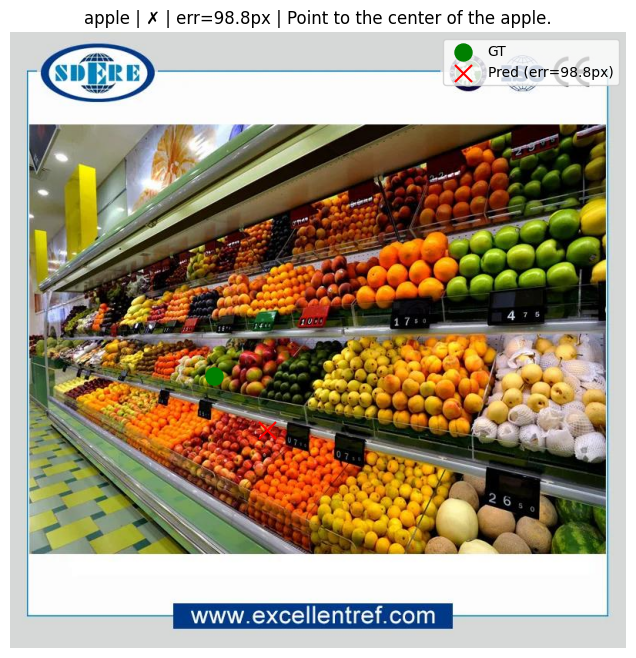

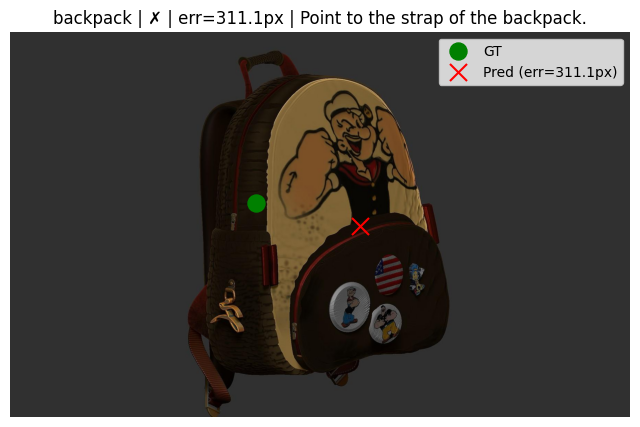

In [ ]:
show_prediction(test_per_image, idx=0)
show_prediction(test_per_image, idx=5)

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/clip_grasp_model_clip_v1.pt")
print("Model saved.")
print(f"\nOutput files saved to: {OUTPUT_DIR}")
print("  clip_val_prompt_eval.json")
print("  clip_val_prompt_summary.json")
print("  clip_val_final_per_image.json")
print("  clip_val_final_per_category.json")
print("  clip_val_final_summary.json")
print("  clip_test_final_per_image.json")
print("  clip_test_final_per_category.json")
print("  clip_test_final_summary.json")